In [1]:
#other imports
import os
import numpy as np
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun

In [28]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
decoded_variables= { 'choice', 'outcome'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [29]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,15,16,18,19,20,21,22]
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,6,8,9,10,11,12,13,15,16,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #1
remove_indices = [0,1,2,8,9,10,11,19,22]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-21', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-06-27', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HA10-1L', '2023-03-31', 'V:')
('HE1-00', '2023-05-30', 'V:')


In [30]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)

model_type = 'GLM_3nmf_pre'
#results_pre,results_pre_all = data_handler.process_multiple_datasets(datasets, model_type)
results_pre,results_pre_all_sb = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives each split!

model_type = 'GLM_3nmf_passive'
#results_pass,results_pass_all = data_handler.process_multiple_datasets(datasets, model_type)
#results_pass,results_pass_all_sb = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA2-1L_2023-05-05
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_pre/decoding/1_1/
decoder_results_regular_outcome.mat
decoder_results_regular_choice.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_pre/decoding/2_1/
decoder_results_regular_outcome.mat
decoder_results_regular_choice.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_pre/decoding/3_1/
decoder_results_regular_outcome.mat
decoder_results_regular_choice.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_pre/decoding/4_1/
decoder_results_regular_outcome.mat
decoder_results_regular_choice.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_pre/decoding/5_1/
decoder_results_regular_outcome.mat
decoder_results_regular_choice.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_pre/decoding/6_1/
decoder_results_regular_outcome.mat
decoder_results_regular_choice.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_pre/decoding/7_1/
decoder_results_regular_outcome.mat
decoder_results_r

In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)

In [32]:
for dataset in results_pre_all_sb:
    print(dataset)
    print(np.shape(results_pre_all_sb[dataset]['outcome']['sc_cumulative_information_mean']))

#del results_pre_all_sb['HE1-00_2023-05-30']

HA2-1L_2023-05-05
(169, 319)
HA1-00_2023-06-29
(169, 159)
HA1-00_2023-08-28
(169, 193)
HE4-1L1R_2023-08-21
(169, 328)
HA11-1R_2023-05-01
(169, 321)
HA11-1R_2023-05-02
(169, 374)
HA2-1L_2023-04-28
(169, 333)
HA2-1L_2023-05-01
(169, 292)
HA1-00_2023-07-07
(169, 203)
HA1-00_2023-08-25
(169, 222)
HA10-1L_2023-03-31
(169, 396)
HE1-00_2023-05-30
(169, 340)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_decoding_results(mean_results_all, decoder_type='choice', plot_type='pop', save_dir=None, xlim = None, ylim = None):
    """
    Plot mean decoding results across datasets.
    
    Args:
        mean_results_all (dict): Dictionary of mean results across datasets
        decoder_type (str): Type of decoding ('choice', 'sound_category', etc.)
        plot_type (str): 'pop' or 'sc' for population or single cell
        save_dir (str): Directory to save plots (optional)
    """
    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    
    # Metrics to plot
    metrics = [
        f'{plot_type}_instantaneous_information_mean',
        f'{plot_type}_cumulative_information_mean',
        f'{plot_type}_instantaneous_fraction_correct_mean',
        f'{plot_type}_cumulative_fraction_correct_mean'
    ]

    # Get event frames from first dataset
    first_dataset = list(mean_results_all.keys())[0]
    event_frames = mean_results_all[first_dataset][decoder_type]['event_frame_mean']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flat
    
    for idx, metric in enumerate(metrics):
        # Collect data across datasets
        all_data = []
        for dataset in mean_results_all.keys():
            if decoder_type in mean_results_all[dataset]:
                data = mean_results_all[dataset][decoder_type][metric]

                # Average across neurons for sc data
                if plot_type == 'sc' and len(data.shape) == 2:  # frames x neurons
                    data = np.mean(data, axis=1)  # average across neurons

                all_data.append(data)
        
        # Calculate mean and SEM across datasets
        all_data = np.array(all_data)
        mean_trace = np.mean(all_data, axis=0)
        sem_trace = np.std(all_data, axis=0) / np.sqrt(len(all_data))
        
        # Plot
        ax = axes[idx]
        x = np.arange(len(mean_trace))
        ax.plot(mean_trace, 'k-', label='Mean')
        ax.fill_between(x, mean_trace-sem_trace, mean_trace+sem_trace, 
                       alpha=0.3, color='gray', label='SEM')
        
        # Add event markers
        for frame in event_frames:
            if frame < xlim[1]:
                ax.axvline(x=frame, color='k', linestyle=':', alpha=0.5)
        
        # Formatting
        ax.set_title(metric.replace('_', ' ').title())
        ax.set_xlabel('Frames')
        if 'information' in metric:
            ax.set_ylabel('Bits')
        else:
            ax.set_ylabel('Fraction Correct')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.set_box_aspect(1)
        if xlim:
            ax.set_xlim(xlim)

        if ylim:
            ax.set_ylim(0,ylim[idx])
        
    plt.tight_layout()
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, f'{decoder_type}_{plot_type}_decoding.png'))
    
    plt.show()



TypeError: 'NoneType' object is not subscriptable

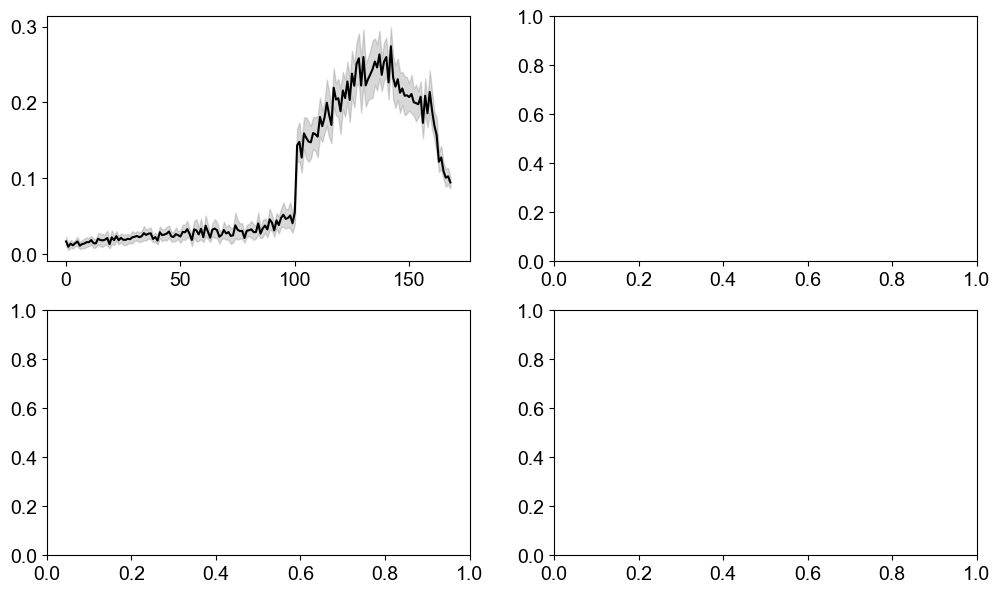

In [35]:
results_pre_all = results_pre_all_sb    
# Usage example:
plot_decoding_results(results_pre_all, 
                     decoder_type= 'choice',
                     plot_type='pop',
                     save_dir=plotter.save_results,
                     #xlim = (0,100),
                     ylim = [0.5, 0.5, 1, 1]) 

In [10]:
# make plots of the mean decoding accuracy
#plotter.plot_decoding_results(results_pre, mouse_dates_keys, 'sound_category', 'choice', 'photostim', 'outcome', 'shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome', save_results, 'pre')

In [23]:
def analyze_peak_responses(mean_results_all, decoder_type='choice', start_frame = 14,end_frame = None):
    """Analyze peak responses for each dataset and neuron."""
    peak_analysis = {}
    
    for dataset in mean_results_all:
        peak_analysis[dataset] = {
            'sc': {},
            'pop': {}
        }
        
        # Single cell metrics
        sc_metrics = [
            'sc_instantaneous_information_mean',
            'sc_cumulative_information_mean',
            'sc_instantaneous_fraction_correct_mean',
            'sc_cumulative_fraction_correct_mean'
        ]
        
        # Population metrics
        pop_metrics = [
            'pop_instantaneous_information_mean',
            'pop_cumulative_information_mean',
            'pop_instantaneous_fraction_correct_mean',
            'pop_cumulative_fraction_correct_mean'
        ]
        
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                
                if end_frame is None:
                    end_frame = len(data)

                # For each neuron
                n_neurons = data.shape[1]
                peaks = []
                peak_frames = []
                
                for n in range(n_neurons):
                    neuron_data = data[start_frame:, n]
                    peak_val = np.max(neuron_data)
                    peak_frame = np.argmax(neuron_data) + start_frame
                    peaks.append(peak_val)
                    peak_frames.append(peak_frame)
                    
                peak_analysis[dataset]['sc'][metric] = {
                    'peak_values': np.array(peaks),
                    'peak_frames': np.array(peak_frames)
                }
        
        # Population metrics
        for metric in pop_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                peak_val = np.max(data[start_frame:])
                peak_frame = np.argmax(data[start_frame:]) + start_frame
                
                peak_analysis[dataset]['pop'][metric] = {
                    'peak_value': peak_val,
                    'peak_frame': peak_frame
                }
    
    return peak_analysis

# # Usage:
# peaks = analyze_peak_responses(results_pre_all, decoder_type='sound_category', start_frame=14)

# # Print example results
# dataset = list(peaks.keys())[0]
# print(f"\nDataset: {dataset}")
# print("\nSingle cell peaks (first 5 neurons):")
# for metric in peaks[dataset]['sc']:
#     print(f"\n{metric}:")
#     print(f"Peak values: {peaks[dataset]['sc'][metric]['peak_values'][:5]}")
#     print(f"Peak frames: {peaks[dataset]['sc'][metric]['peak_frames'][:5]}")

# print("\nPopulation peaks:")
# for metric in peaks[dataset]['pop']:
#     print(f"\n{metric}:")
#     print(f"Peak value: {peaks[dataset]['pop'][metric]['peak_value']}")
#     print(f"Peak frame: {peaks[dataset]['pop'][metric]['peak_frame']}")

In [24]:
# class DecodingAnalyzer:
#     def __init__(self):
#         self.cell_types = ['pyr', 'som', 'pv']
#         self.metrics = {
#             'sc': ['sc_instantaneous_information_mean',
#                   'sc_cumulative_information_mean',
#                   'sc_instantaneous_fraction_correct_mean',
#                   'sc_cumulative_fraction_correct_mean'],
#             'pop': ['pop_instantaneous_information_mean',
#                    'pop_cumulative_information_mean',
#                    'pop_instantaneous_fraction_correct_mean',
#                    'pop_cumulative_fraction_correct_mean']
#         }

def analyze_peaks_by_celltype( mean_results_all, decoder_type='sound_category', start_frame = 14,end_frame = None):
    """Analyze peak responses separated by cell type."""
    peaks_by_celltype = {
        dataset: {
            celltype: {
                'sc': {},
                'pop': {}
            } for celltype in mean_results_all[dataset]['neuron_groups']
        } for dataset in mean_results_all
    }


    # Single cell metrics
    sc_metrics = [
        'sc_instantaneous_information_mean',
        'sc_cumulative_information_mean',
        'sc_instantaneous_fraction_correct_mean',
        'sc_cumulative_fraction_correct_mean'
    ]

    # Population metrics
    pop_metrics = [
        'pop_instantaneous_information_mean',
        'pop_cumulative_information_mean',
        'pop_instantaneous_fraction_correct_mean',
        'pop_cumulative_fraction_correct_mean'
    ]
    
    for dataset in mean_results_all:
        celltype_array = mean_results_all[dataset]['celltype_array']
        
        # Get indices for each cell type
        celltype_indices = {
            'pyr': np.where(celltype_array == 0)[0],
            'som': np.where(celltype_array == 1)[0],
            'pv': np.where(celltype_array == 2)[0]
        }

        # Process single cell metrics
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                
                if end_frame is None:
                    end_frame = len(data)
                    
                for celltype, indices in celltype_indices.items():
                    peaks = []
                    peak_frames = []
                    
                    for idx in indices:
                        neuron_data = data[start_frame:end_frame, idx]
                        peak_val = np.max(neuron_data)
                        peak_frame = np.argmax(neuron_data) + start_frame
                        peaks.append(peak_val)
                        peak_frames.append(peak_frame)
                    
                    peaks_by_celltype[dataset][celltype]['sc'][metric] = {
                        'peak_values': np.array(peaks),
                        'peak_frames': np.array(peak_frames),
                        'mean_peak': np.mean(peaks),
                        'sem_peak': np.std(peaks) / np.sqrt(len(peaks))
                    }

        # Process population metrics
        for metric in pop_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                peak_val = np.max(data[start_frame:])
                peak_frame = np.argmax(data[start_frame:]) + start_frame
                for celltype, indices in celltype_indices.items():
                    
                    peaks_by_celltype[dataset][celltype]['pop'][metric] = {
                        'peak_value': peak_val,
                        'peak_frame': peak_frame
                    }

    return peaks_by_celltype


In [25]:
peaks_by_celltype = analyze_peaks_by_celltype( results_pre_all, decoder_type='photostim', start_frame=14, end_frame = 100)

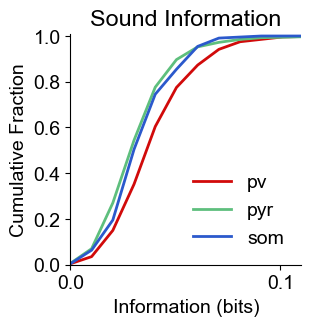

In [26]:
def format_peaks_for_cdf(peaks_by_celltype, metric='sc_instantaneous_information_mean'):
    """
    Format peaks data to match coupling index structure for CDF plotting
    
    Returns dict structure:
    {
        'pyr': {model_type: [values]},
        'som': {model_type: [values]},
        'pv': {model_type: [values]}
    }
    """
    formatted_data = {
        'pyr': {'peaks': []},
        'som': {'peaks': []},
        'pv': {'peaks': []},
        'all': {'peaks': []}    
    }
    all_peaks = []
    cell_labels = []
    # Collect peaks across datasets
    for dataset in peaks_by_celltype:
        for celltype in ['pyr', 'som', 'pv']:
            peak_values = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_values']
            formatted_data[celltype]['peaks'].extend(peak_values)
            all_peaks.extend(peak_values)
            cell_labels.extend([celltype] * len(peak_values))
    # Format like coupling index data
    formatted_data = {'all': {'peaks': all_peaks}}

    return formatted_data, cell_labels

# Usage:
cdf_data, cell_labels = format_peaks_for_cdf(peaks_by_celltype)
# cell_labels = []
# for dataset_key, dataset in results_pre_all.items():

#     # if significant_neurons and dataset_key in significant_neurons:
#     #     cell_ids = significant_neurons[dataset_key][0]
#     # else:
#     #     cell_ids = range(len(dataset['celltype_array']))  # Default to all cells
#     cell_ids = range(len(dataset['celltype_array']))
#     cell_types = {
#                 0: 'pyr',
#                 1: 'som',
#                 2: 'pv',
#             }
#     # cell_labels.extend([cell_types[dataset['celltype_array'][i]] for i in cell_ids])
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),cell_labels,colors = plotter.celltypecolors,title='Sound Information', xlabel = 'Information (bits)', xval=.1,xint=0.1)

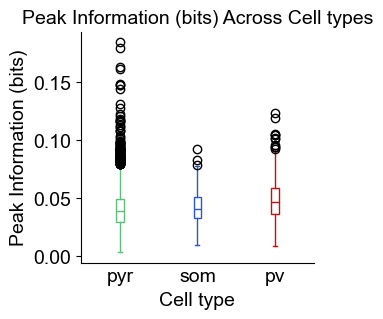

In [27]:
def format_peaks_for_boxplot(peaks_by_celltype, metric='sc_instantaneous_information_mean'):
    # Collect all peaks and indices
    all_peaks = []
    neuron_groups = {'pyr': [], 'som': [], 'pv': []}
    current_idx = 0
    
    # Collect peaks across datasets
    for dataset in peaks_by_celltype:
        for celltype in ['pyr', 'som', 'pv']:
            peak_values = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_values']
            all_peaks.extend(peak_values)
            # Store indices for this cell type
            indices = list(range(current_idx, current_idx + len(peak_values)))
            neuron_groups[celltype].extend(indices)
            current_idx += len(peak_values)
    
    return np.array(all_peaks), neuron_groups

# Usage
all_peaks, neuron_groups = format_peaks_for_boxplot(peaks_by_celltype)
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)'
)

In [16]:
def plot_decoding_analysis(results_dict, decoder_type='sound_category'):
    """Create suite of analysis plots"""
    
    # 1. Time series plot with mean±SEM across datasets
    plt.figure(figsize=(10,6))
    all_data = []
    for dataset in results_dict:
        data = results_dict[dataset][decoder_type]['pop_cumulative_information_mean']
        all_data.append(data)
    
    mean_trace = np.mean(all_data, axis=0)
    sem_trace = np.std(all_data, axis=0) / np.sqrt(len(all_data))
    plt.plot(mean_trace, 'b-', label='Mean')
    plt.fill_between(range(len(mean_trace)), 
                    mean_trace-sem_trace, 
                    mean_trace+sem_trace,
                    alpha=0.3)
    plt.title(f'{decoder_type} Decoding Performance')
    plt.xlabel('Time (frames)')
    plt.ylabel('Information (bits)')
    
    # 2. Compare instantaneous vs cumulative
    # plt.figure(figsize=(10,6))
    # for metric in ['pop_instantaneous_information_mean', 'pop_cumulative_information_mean']:
    #     all_data = []
    #     for dataset in results_dict:
    #         data = results_dict[dataset][decoder_type][metric]
    #         all_data.append(data)
    #     mean_trace = np.mean(all_data, axis=0)
    #     plt.plot(mean_trace, label=metric.split('_')[1])
    # plt.legend()
    # plt.title('Instantaneous vs Cumulative Information')
    
    # 3. Peak information by cell type boxplot
    peaks_by_celltype = analyze_peaks_by_celltype( results_dict, decoder_type=decoder_type, start_frame=14, end_frame = 100)
    all_peaks, neuron_groups = format_peaks_for_boxplot(peaks_by_celltype)
    plotter.box_plot(all_peaks, 
                     neuron_groups,
                     plotter.celltypecolors,
                     'Peak Information')
    
    # 4. Information timeline heatmap
    plt.figure(figsize=(12,len(results_dict)))
    data_matrix = np.array([results_dict[d][decoder_type]['pop_instantaneous_information_mean'] 
                           for d in results_dict])
    sns.heatmap(data_matrix, 
                xticklabels=20, 
                yticklabels=list(results_dict.keys()),
                cmap='viridis')
    plt.title('Information Evolution Across Datasets')
    plt.xlabel('Time (frames)')
    
    plt.tight_layout()
    plt.show()
plot_decoding_analysis(results_pass_all_sb, decoder_type='sound_category')

NameError: name 'results_pass_all_sb' is not defined

C:\Users\RUNYAN1\AppData\Local\Temp\ipykernel_28748\4172933451.py:20: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\RUNYAN1\AppData\Local\Temp\ipykernel_28748\4172933451.py:29: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  celltype_idx = results_dict[dataset]['celltype_array'] == celltype
C:\Users\RUNYAN1\AppData\Local\Temp\ipykernel_28748\4172933451.py:46: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  celltype_idx = results_dict[dataset]['celltype_array'] == celltype
C:\Users\RUNYAN1\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\RUNYAN1\AppData\Roaming\Python\Python311\site-packages\numpy

TypeError: object of type 'numpy.float64' has no len()

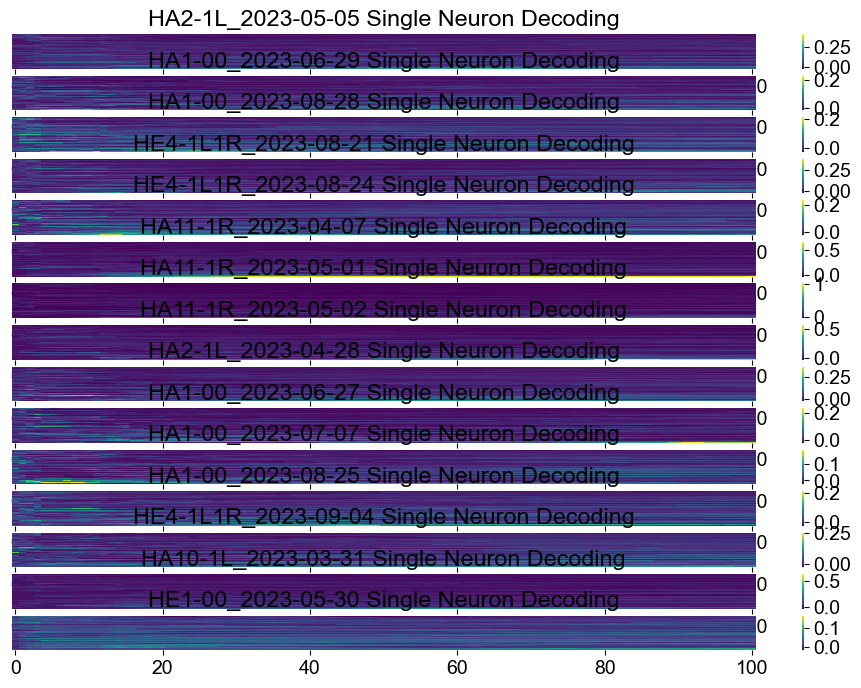

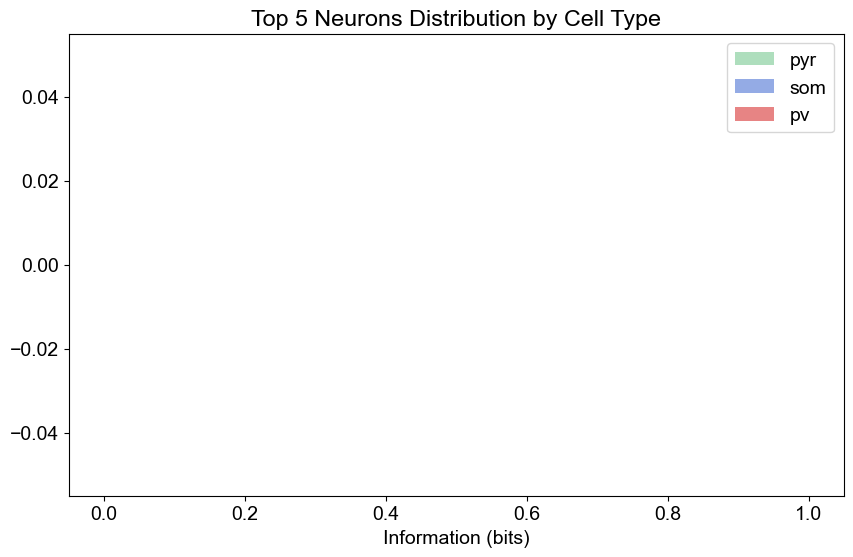

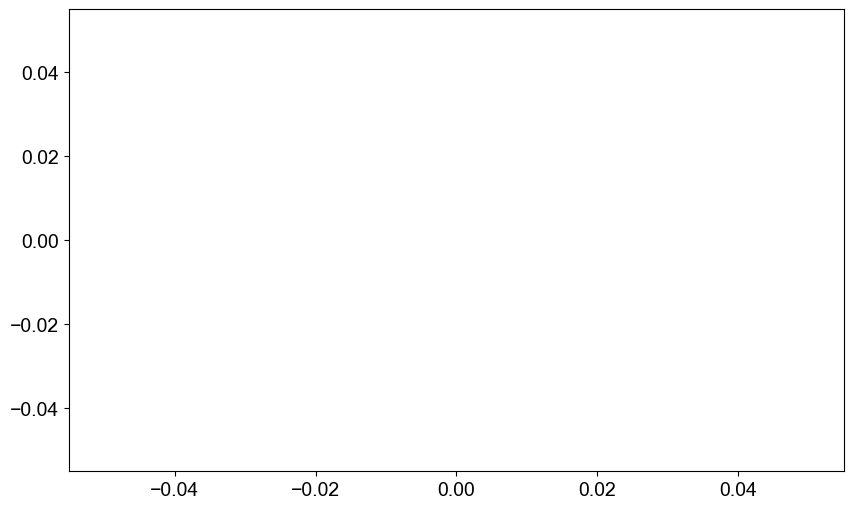

In [ ]:
def plot_single_neuron_analysis(results_dict, decoder_type='sound_category', start_frame=14):
    """Comprehensive single neuron decoding visualization"""
    
    # 1. Neuron Performance Heatmap
    plt.figure(figsize=(12, 8))
    for dataset in results_dict:
        data = results_dict[dataset][decoder_type]['sc_cumulative_information_mean']
        celltype_array = results_dict[dataset]['celltype_array']
        
        # Sort neurons by cell type and performance
        max_info = np.max(data[start_frame:, :], axis=0)
        sort_idx = np.argsort(max_info)
        
        plt.subplot(len(results_dict), 1, list(results_dict.keys()).index(dataset) + 1)
        sns.heatmap(data[:, sort_idx].T, 
                   cmap='viridis',
                   xticklabels=20,
                   yticklabels=False)
        plt.title(f'{dataset} Single Neuron Decoding')
    plt.tight_layout()
    
    # 2. Best Neurons Analysis
    plt.figure(figsize=(10, 6))
    for celltype, color in plotter.celltypecolors.items():
        all_peaks = []
        for dataset in results_dict:
            peaks_by_celltype = analyze_peaks_by_celltype( results_dict, decoder_type=decoder_type, start_frame=14, end_frame = 100)
            peaks = peaks_by_celltype[dataset][celltype]['sc']['sc_cumulative_information_mean']['peak_values']
            celltype_idx = results_dict[dataset]['celltype_array'] == celltype
            if np.any(celltype_idx):
                max_peaks = np.max(peaks[start_frame:, celltype_idx], axis=0)
                top_5 = np.sort(max_peaks)[-5:]
                all_peaks.extend(top_5)
        
        plt.hist(all_peaks, alpha=0.5, color=color, label=celltype)
    plt.legend()
    plt.title('Top 5 Neurons Distribution by Cell Type')
    plt.xlabel('Information (bits)')
    
    # 3. Time Course by Cell Type
    plt.figure(figsize=(10, 6))
    for celltype, color in plotter.celltypecolors.items():
        all_traces = []
        for dataset in results_dict:
            traces = results_dict[dataset][decoder_type]['sc_cumulative_information_mean']
            celltype_idx = results_dict[dataset]['celltype_array'] == celltype
            if np.any(celltype_idx):
                mean_trace = np.mean(traces[:, celltype_idx], axis=1)
                all_traces.append(mean_trace)
        
        mean = np.mean(all_traces, axis=0)
        sem = np.std(all_traces, axis=0) / np.sqrt(len(all_traces))
        plt.plot(mean, color=color, label=celltype)
        plt.fill_between(range(len(mean)), mean-sem, mean+sem, alpha=0.2, color=color)
    
    plt.legend()
    plt.title('Average Information Time Course by Cell Type')
    plt.xlabel('Time (frames)')
    plt.ylabel('Information (bits)')
    
    plt.show()
plot_single_neuron_analysis(results_pass_all_sb, decoder_type='sound_category', start_frame=14)